Import Libraries and Load Data

In [1]:
# import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from scipy import stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("libraries loaded!")

libraries loaded!


Load Data

In [2]:
import os
os.chdir("C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project")

# connect to database
conn = sqlite3.connect("data/db/bluestock_mf.db")

# load tables
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
nav_history = pd.read_sql("SELECT * FROM fact_nav", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)

# load benchmark data
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

# fix dates
nav_history['date'] = pd.to_datetime(nav_history['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("data loaded!")
print(f"funds: {len(fund_master)}")
print(f"nav records: {len(nav_history)}")
print(f"benchmark records: {len(benchmark)}")

data loaded!
funds: 40
nav records: 46000
benchmark records: 8050


Daily Returns

calculating daily returns...

daily returns summary:
average return: 0.0631%
min return: -5.81%
max return: 6.47%


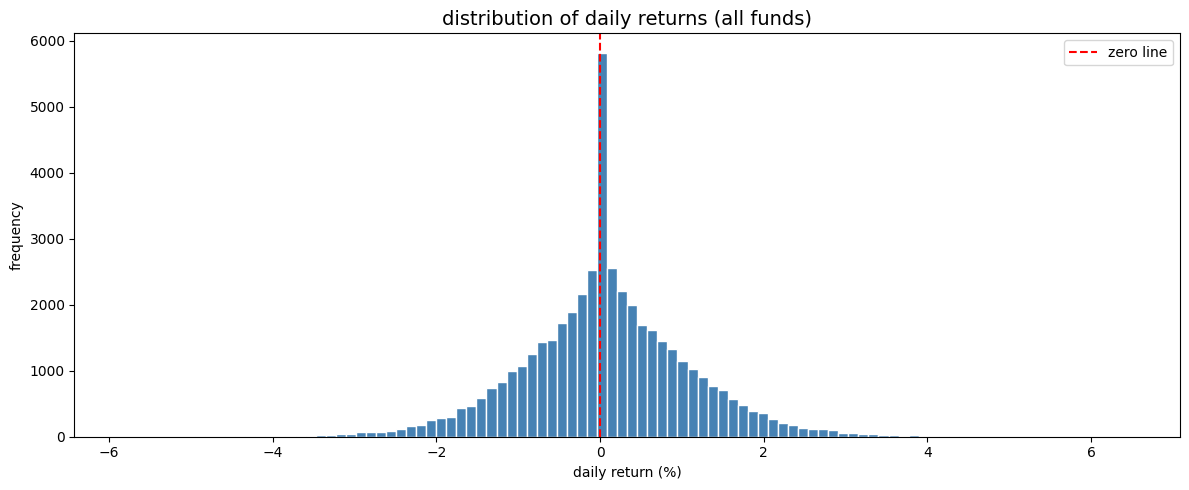


returns look reasonable!


In [3]:
# STEP 1: CALCULATE DAILY RETURNS FOR ALL 40 FUNDS
# formula: daily_return = (nav today / nav yesterday) - 1

print("calculating daily returns...")

# sort by fund and date first
nav_history = nav_history.sort_values(['amfi_code', 'date'])

# calculate daily return for each fund separately
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()

# remove first row of each fund (no previous day to compare)
returns_clean = nav_history.dropna(subset=['daily_return']).copy()

# check if returns look reasonable
print(f"\ndaily returns summary:")
print(f"average return: {returns_clean['daily_return'].mean()*100:.4f}%")
print(f"min return: {returns_clean['daily_return'].min()*100:.2f}%")
print(f"max return: {returns_clean['daily_return'].max()*100:.2f}%")

# plot distribution of returns
plt.figure(figsize=(12, 5))
plt.hist(returns_clean['daily_return'] * 100, bins=100, color='steelblue', edgecolor='white')
plt.title('distribution of daily returns (all funds)', fontsize=14)
plt.xlabel('daily return (%)')
plt.ylabel('frequency')
plt.axvline(x=0, color='red', linestyle='--', label='zero line')
plt.legend()
plt.tight_layout()
plt.savefig('reports/10_returns_distribution.png', dpi=300)
plt.show()

print("\nreturns look reasonable!")

CAGR (Compound Annual Growth Rate)
CAGR tells us how much a fund grew every year on average.

Example:
- I invested ₹1000 in 2021
- It became ₹1500 in 2024 (3 years)
- CAGR = 14.47% per year

Formula:
CAGR = (End Value / Start Value) ^ (1/Years) - 1

Higher CAGR = Better fund performance

In [4]:
# STEP 2: CALCULATE CAGR FOR 1 YEAR, 3 YEAR, 5 YEAR
# formula: CAGR = (nav_end / nav_start) ^ (1/n) - 1

print("calculating CAGR for all funds...")

# get latest date in data
latest_date = nav_history['date'].max()
print(f"latest date: {latest_date.date()}")

# define time periods
periods = {
    '1yr': 1,
    '3yr': 3,
    '5yr': 5
}

cagr_results = []

for code in fund_master['amfi_code'].unique():
    # get nav data for this fund
    fund_nav = nav_history[nav_history['amfi_code'] == code].sort_values('date')
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    
    row = {'amfi_code': code, 'scheme_name': fund_name}
    
    for period_name, years in periods.items():
        # find start date (n years ago)
        start_date = latest_date - pd.DateOffset(years=years)
        
        # get nav at start and end
        nav_end = fund_nav[fund_nav['date'] <= latest_date]['nav'].iloc[-1]
        nav_start_data = fund_nav[fund_nav['date'] >= start_date]
        
        if len(nav_start_data) > 0:
            nav_start = nav_start_data['nav'].iloc[0]
            # calculate CAGR
            cagr = (nav_end / nav_start) ** (1/years) - 1
            row[f'cagr_{period_name}'] = round(cagr * 100, 2)
        else:
            row[f'cagr_{period_name}'] = None
    
    cagr_results.append(row)

# create dataframe
cagr_df = pd.DataFrame(cagr_results)
print("\nCAGR comparison table:")
print(cagr_df[['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].to_string(index=False))

# save to csv
cagr_df.to_csv('data/processed/cagr_results.csv', index=False)
print("\nsaved to data/processed/cagr_results.csv")

calculating CAGR for all funds...
latest date: 2026-05-29

CAGR comparison table:
                                          scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
            SBI Bluechip Fund - Regular Plan - Growth     60.44     30.46     22.38
             SBI Bluechip Fund - Direct Plan - Growth      5.71     16.27     18.71
           SBI Small Cap Fund - Regular Plan - Growth     82.78     26.67     28.03
            SBI Small Cap Fund - Direct Plan - Growth     13.95     -1.34      1.81
         SBI Magnum Gilt Fund - Regular Plan - Growth      5.52      5.84      5.16
            HDFC Top 100 Fund - Regular Plan - Growth     -2.22      1.29      2.32
             HDFC Top 100 Fund - Direct Plan - Growth     28.68     18.43     16.56
   HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.23     32.44     26.07
    HDFC Mid-Cap Opportunities Fund - Direct - Growth     15.44     11.25      9.88
         HDFC Short Term Debt Fund - Regular - Growth      3.70      3.92     

Sharpe Ratio
Sharpe Ratio tells us if a fund is giving good returns
for the risk it is taking.

Example:
- Fund A gives 20% returns but is very risky
- Fund B gives 15% returns but is less risky
- Fund B has better Sharpe Ratio!

Formula:
Sharpe = (Fund Return - 6.5%) / Standard Deviation x √252

We use 6.5% because that is what a safe FD gives in India.

Higher Sharpe = Better risk adjusted returns
Above 1.0 = Good fund
Above 2.0 = Excellent fund

In [5]:
# STEP 3: CALCULATE SHARPE RATIO
# formula: sharpe = (avg_return - risk_free_rate) / std_return * sqrt(252)
# risk free rate = 6.5% per year = 6.5/252 per day

print("calculating sharpe ratios...")

# daily risk free rate
rf_daily = 0.065 / 252

sharpe_results = []

for code in fund_master['amfi_code'].unique():
    # get daily returns for this fund
    fund_returns = returns_clean[returns_clean['amfi_code'] == code]['daily_return']
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    
    if len(fund_returns) > 30:
        # calculate sharpe ratio
        avg_return = fund_returns.mean()
        std_return = fund_returns.std()
        
        sharpe = (avg_return - rf_daily) / std_return * np.sqrt(252)
        
        sharpe_results.append({
            'amfi_code': code,
            'scheme_name': fund_name,
            'avg_daily_return': round(avg_return * 100, 4),
            'std_daily_return': round(std_return * 100, 4),
            'sharpe_ratio': round(sharpe, 3)
        })

# create dataframe and rank
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False)
sharpe_df['sharpe_rank'] = range(1, len(sharpe_df) + 1)

print("\ntop 10 funds by sharpe ratio:")
print(sharpe_df[['scheme_name', 'sharpe_ratio', 'sharpe_rank']].head(10).to_string(index=False))

calculating sharpe ratios...

top 10 funds by sharpe ratio:
                                       scheme_name  sharpe_ratio  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth         1.448            1
            Kotak Flexicap Fund - Regular - Growth         1.307            2
     Mirae Asset Tax Saver Fund - Regular - Growth         1.235            3
         SBI Bluechip Fund - Regular Plan - Growth         1.208            4
          ICICI Pru Midcap Fund - Regular - Growth         1.180            5
                DSP Midcap Fund - Regular - Growth         1.132            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.094            7
    Nippon India Large Cap Fund - Regular - Growth         1.082            8
     ABSL Frontline Equity Fund - Regular - Growth         1.027            9
         ICICI Pru Bluechip Fund - Direct - Growth         1.027           10


Sortino Ratio
Sortino Ratio is similar to Sharpe Ratio but only looks
at the bad days (when fund lost money).

It is better than Sharpe because it does not punish
a fund for going UP a lot, only for going DOWN.

Formula:
Sortino = (Fund Return - 6.5%) / Downside Deviation x √252

Higher Sortino = Fund handles losses better

In [6]:
# STEP 4: CALCULATE SORTINO RATIO
# same as sharpe but only uses negative returns for std calculation

print("calculating sortino ratios...")

sortino_results = []

for code in fund_master['amfi_code'].unique():
    fund_returns = returns_clean[returns_clean['amfi_code'] == code]['daily_return']
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    
    if len(fund_returns) > 30:
        avg_return = fund_returns.mean()
        
        # only use negative returns for downside std
        negative_returns = fund_returns[fund_returns < 0]
        downside_std = negative_returns.std()
        
        sortino = (avg_return - rf_daily) / downside_std * np.sqrt(252)
        
        sortino_results.append({
            'amfi_code': code,
            'scheme_name': fund_name,
            'sortino_ratio': round(sortino, 3)
        })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False)

print("\ntop 10 funds by sortino ratio:")
print(sortino_df[['scheme_name', 'sortino_ratio']].head(10).to_string(index=False))

calculating sortino ratios...

top 10 funds by sortino ratio:
                                       scheme_name  sortino_ratio
     Mirae Asset Large Cap Fund - Regular - Growth          2.386
            Kotak Flexicap Fund - Regular - Growth          2.364
     Mirae Asset Tax Saver Fund - Regular - Growth          2.147
         SBI Bluechip Fund - Regular Plan - Growth          2.140
          ICICI Pru Midcap Fund - Regular - Growth          2.029
                DSP Midcap Fund - Regular - Growth          1.875
    Nippon India Large Cap Fund - Regular - Growth          1.850
HDFC Mid-Cap Opportunities Fund - Regular - Growth          1.829
         ICICI Pru Bluechip Fund - Direct - Growth          1.805
     ABSL Frontline Equity Fund - Regular - Growth          1.800


Alpha and Beta
BETA tells us how much a fund moves compared to the market.
- Beta = 1.0 means fund moves same as market
- Beta = 1.2 means fund moves 20% more than market
- Beta = 0.8 means fund moves 20% less than market

ALPHA tells us if the fund manager is doing a good job.
- Alpha = 3% means fund beat the market by 3%
- Alpha = 0% means fund just matched the market
- Alpha = -2% means fund did worse than market

Higher Alpha = Fund manager is adding value
Higher Beta = Fund is more risky

In [8]:
# check what benchmark index names exist in our data
print("Available benchmark indices:")
print(benchmark['index_name'].unique())
print("\nBenchmark date range:")
print(f"From: {benchmark['date'].min()}")
print(f"To: {benchmark['date'].max()}")
print(f"\nTotal records: {len(benchmark)}")

Available benchmark indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

Benchmark date range:
From: 2022-01-03 00:00:00
To: 2026-05-29 00:00:00

Total records: 8050


In [9]:
# STEP 5: CALCULATE ALPHA AND BETA
# using linear regression of fund returns vs nifty 100 returns

print("calculating alpha and beta...")

# prepare nifty 100 benchmark returns
# using correct name 'NIFTY100' from our data
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

print(f"nifty100 records: {len(nifty100)}")

alpha_beta_results = []

for code in fund_master['amfi_code'].unique():
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    
    # get fund returns
    fund_ret = returns_clean[returns_clean['amfi_code'] == code][['date', 'daily_return']]
    
    # merge with benchmark returns
    merged = pd.merge(fund_ret, nifty100[['date', 'benchmark_return']], on='date', how='inner')
    
    if len(merged) > 30:
        # run linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )
        
        beta = round(slope, 3)
        alpha = round(intercept * 252 * 100, 3)
        
        alpha_beta_results.append({
            'amfi_code': code,
            'scheme_name': fund_name,
            'alpha': alpha,
            'beta': beta,
            'r_squared': round(r_value**2, 3)
        })

print(f"funds processed: {len(alpha_beta_results)}")

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("\nalpha beta results:")
print(alpha_beta_df[['scheme_name', 'alpha', 'beta', 'r_squared']].to_string(index=False))

# save to csv
alpha_beta_df.to_csv('data/processed/alpha_beta.csv', index=False)
print("\nsaved to data/processed/alpha_beta.csv")

calculating alpha and beta...
nifty100 records: 1149
funds processed: 40

alpha beta results:
                                          scheme_name  alpha   beta  r_squared
            SBI Bluechip Fund - Regular Plan - Growth 23.201 -0.032      0.001
             SBI Bluechip Fund - Direct Plan - Growth 19.869 -0.026      0.001
           SBI Small Cap Fund - Regular Plan - Growth 30.337 -0.023      0.000
            SBI Small Cap Fund - Direct Plan - Growth  4.882  0.062      0.001
         SBI Magnum Gilt Fund - Regular Plan - Growth  5.621 -0.006      0.000
            HDFC Top 100 Fund - Regular Plan - Growth  3.748 -0.058      0.003
             HDFC Top 100 Fund - Direct Plan - Growth 17.730  0.049      0.002
   HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.195  0.005      0.000
    HDFC Mid-Cap Opportunities Fund - Direct - Growth 11.989  0.009      0.000
         HDFC Short Term Debt Fund - Regular - Growth  4.282  0.001      0.000
           ICICI Pru Bluechip Fund - 

Maximum Drawdown
Maximum Drawdown tells us the worst loss a fund ever had.

Example:
- Fund was at ₹100 in January
- It fell to ₹75 in March
- Maximum Drawdown = -25%

This tells us the worst case scenario for an investor.

Lower Drawdown = Safer fund

In [10]:
# STEP 6: CALCULATE MAXIMUM DRAWDOWN
# formula: min(nav / running_max - 1)

print("calculating maximum drawdown...")

drawdown_results = []

for code in fund_master['amfi_code'].unique():
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    fund_nav = nav_history[nav_history['amfi_code'] == code].sort_values('date')
    
    # calculate running maximum
    fund_nav['running_max'] = fund_nav['nav'].cummax()
    
    # calculate drawdown
    fund_nav['drawdown'] = fund_nav['nav'] / fund_nav['running_max'] - 1
    
    # find maximum drawdown
    max_dd = fund_nav['drawdown'].min()
    max_dd_date = fund_nav.loc[fund_nav['drawdown'].idxmin(), 'date']
    
    drawdown_results.append({
        'amfi_code': code,
        'scheme_name': fund_name,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'worst_date': max_dd_date.date()
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.sort_values('max_drawdown_pct')

print("\nworst drawdowns:")
print(drawdown_df[['scheme_name', 'max_drawdown_pct', 'worst_date']].head(10).to_string(index=False))

calculating maximum drawdown...

worst drawdowns:
                                   scheme_name  max_drawdown_pct worst_date
     SBI Small Cap Fund - Direct Plan - Growth            -52.57 2025-10-28
        Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
        ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
         DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth            -28.71 2025-05-14
           UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth            -24.00 2024-10-17
Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-02-20
          Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22


Fund Scorecard
Fund Scorecard gives each fund a score from 0 to 100.
It combines multiple metrics to rank all funds fairly.

Score = 
  30% x 3 year returns rank
+ 25% x Sharpe ratio rank  
+ 20% x Alpha rank
+ 15% x Expense ratio rank (lower fee = better)
+ 10% x Max drawdown rank (lower loss = better)

Higher Score = Better overall fund

In [11]:
# STEP 7: FUND SCORECARD (0-100)
# 30% x 3yr return rank + 25% x sharpe rank + 20% x alpha rank
# + 15% x expense ratio rank (lower is better) + 10% x max drawdown rank (lower is better)

print("creating fund scorecard...")

# merge all metrics
scorecard = fund_master[['amfi_code', 'scheme_name', 'expense_ratio_pct']].copy()
scorecard = scorecard.merge(cagr_df[['amfi_code', 'cagr_3yr']], on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(drawdown_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left')

# rank each metric
total_funds = len(scorecard)

# higher is better for these
scorecard['rank_3yr'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=False)

# lower is better for these (inverse rank)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['rank_drawdown'] = scorecard['max_drawdown_pct'].rank(ascending=False)

# calculate composite score (0-100)
scorecard['score'] = (
    0.30 * (1 - scorecard['rank_3yr'] / total_funds) * 100 +
    0.25 * (1 - scorecard['rank_sharpe'] / total_funds) * 100 +
    0.20 * (1 - scorecard['rank_alpha'] / total_funds) * 100 +
    0.15 * (1 - scorecard['rank_expense'] / total_funds) * 100 +
    0.10 * (1 - scorecard['rank_drawdown'] / total_funds) * 100
)

scorecard['score'] = scorecard['score'].round(2)
scorecard = scorecard.sort_values('score', ascending=False)
scorecard['overall_rank'] = range(1, len(scorecard) + 1)

print("\ntop 10 funds by scorecard:")
print(scorecard[['scheme_name', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'score', 'overall_rank']].head(10).to_string(index=False))

# save to csv
scorecard.to_csv('data/processed/fund_scorecard.csv', index=False)
print("\nsaved to data/processed/fund_scorecard.csv")

creating fund scorecard...

top 10 funds by scorecard:
                                       scheme_name  cagr_3yr  sharpe_ratio  alpha  score  overall_rank
     Mirae Asset Large Cap Fund - Regular - Growth     34.00         1.448 26.984  83.75             1
          ICICI Pru Midcap Fund - Regular - Growth     31.78         1.180 29.264  79.75             2
            Kotak Flexicap Fund - Regular - Growth     29.58         1.307 27.330  79.50             3
HDFC Mid-Cap Opportunities Fund - Regular - Growth     32.44         1.094 27.195  78.25             4
         ICICI Pru Bluechip Fund - Direct - Growth     32.49         1.027 21.195  77.81             5
               Axis Midcap Fund - Regular - Growth     35.11         0.998 26.077  74.50             6
         SBI Bluechip Fund - Regular Plan - Growth     30.46         1.208 23.201  72.31             7
     Mirae Asset Tax Saver Fund - Regular - Growth     29.18         1.235 28.270  71.19             8
     ABSL Frontlin

Benchmark Comparison Chart

In [15]:
# STEP 8: BENCHMARK COMPARISON CHART
# top 5 funds vs nifty 50 and nifty 100

print("creating benchmark comparison chart...")

# get top 5 funds by score
top5_codes = scorecard.head(5)['amfi_code'].tolist()

# filter to last 3 years
three_years_ago = nav_history['date'].max() - pd.DateOffset(years=3)
nav_3yr = nav_history[
    (nav_history['amfi_code'].isin(top5_codes)) &
    (nav_history['date'] >= three_years_ago)
].copy()

# normalize to 100 at start (so all start at same point)
fig = go.Figure()

for code in top5_codes:
    fund_data = nav_3yr[nav_3yr['amfi_code'] == code].sort_values('date')
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0][:25]
    
    # normalize to 100
    start_nav = fund_data['nav'].iloc[0]
    fund_data['normalized'] = fund_data['nav'] / start_nav * 100
    
    fig.add_trace(go.Scatter(
        x=fund_data['date'],
        y=fund_data['normalized'],
        mode='lines',
        name=fund_name
    ))

# add nifty 50
for index_name in ['Nifty 50', 'Nifty 100']:
    idx_data = benchmark[
        (benchmark['index_name'] == index_name) &
        (benchmark['date'] >= three_years_ago.strftime('%Y-%m-%d'))
    ].sort_values('date').copy()
    
    if len(idx_data) > 0:
        start_val = idx_data['close_value'].iloc[0]
        idx_data['normalized'] = idx_data['close_value'] / start_val * 100
        
        fig.add_trace(go.Scatter(
            x=idx_data['date'],
            y=idx_data['normalized'],
            mode='lines',
            name=index_name,
            line=dict(dash='dash', width=2)
        ))

fig.update_layout(
    title='Top 5 Funds vs Benchmark (Last 3 Years, Normalized to 100)',
    xaxis_title='Date',
    yaxis_title='Normalized Value (Base = 100)',
    height=550,
    hovermode='x unified'
)

# save as html 
fig.write_html('reports/11_benchmark_comparison.html')

# save as png
fig.write_image('reports/11_benchmark_comparison.png')
fig.show()
print("chart saved!")

creating benchmark comparison chart...


ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
